`HIPÓTESE 6`: 

“Eventos climáticos negativos (seca, calor extremo) geram movimentos de preço e/ou volatilidade mais intensos do que positivos equivalentes (chuva ideal, clima ameno), mesmo com desvios similares em relação à média histórica.”​


 $H_0$: 
 "Eventos climáticos negativos geram movimentos de preço/volatilidade com intensidade igual ou menor que eventos positivos equivalentes."
  $$H_0: I_{negativo} \le I_{positivo}$$
 
 $H_1$:
 "Eventos climáticos negativos geram movimentos de preço/volatilidade com intensidade estatisticamente maior do que eventos positivos equivalentes."
  $$H_1: I_{negativo} > I_{positivo}$$

In [14]:
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from src.agro_predictor.data_loaders.tools_hipotese import (testar_hipotese6, 
                                                            testar_hipotese_ajustada6, 
                                                            carregar_dados_agro)


In [2]:
# Carregar dados

df_hipotese = carregar_dados_agro()

384: 🚀 Conectando ao Banco (Local): localhost:5435
Carregando dados pré-processados da View para hipotese1: ZS=F...


In [3]:
df_hipotese['climate_category'].isnull().sum()

0

In [4]:
# Preparação dos Grupos

negativo = df_hipotese[df_hipotese['climate_category'] == 'Negative_Shock']['price_intensity'].dropna()
positivo = df_hipotese[df_hipotese['climate_category'] == 'Positive_Ideal']['price_intensity'].dropna()

In [5]:
# Executando para Intensidade de Preço

testar_hipotese6(negativo, positivo, "Intensidade de Movimento (ABS % Change)")

--- Análise de Hipótese para: Intensidade de Movimento (ABS % Change) ---
Média Intensidade (Negativa): 0.0107
Média Intensidade (Positiva): nan
Estatística T: nan
P-Value: nan
RESULTADO: Falha em rejeitar H0. Não há diferença estatística significante.




c:\Users\Sergio\Desktop\_ESTUDO\_portifolio_full\agricultura\Agro_predictor_commodities_com_IA\.venv\Lib\site-packages\scipy\_lib\deprecation.py:234: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  return f(*args, **kwargs)


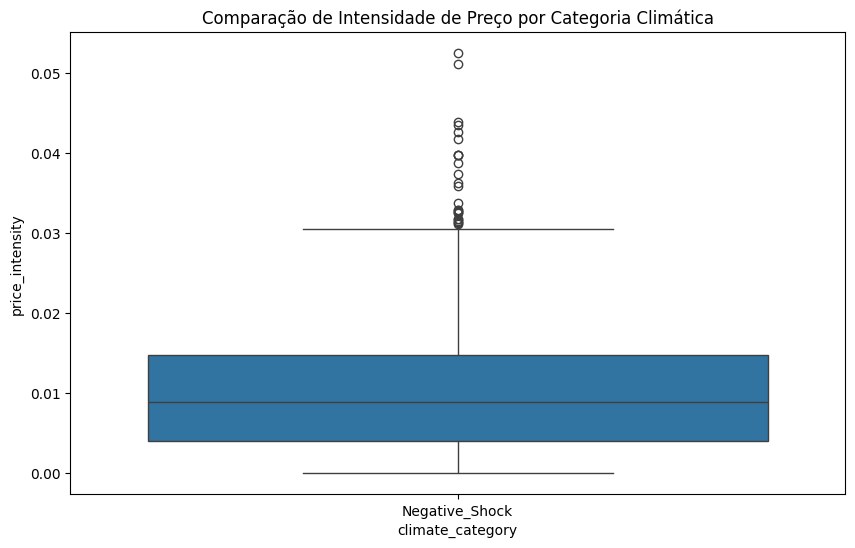

In [6]:
# Visualização (Boxplot) para confirmar a distribuição

plt.figure(figsize=(10, 6))
sns.boxplot(x='climate_category', y='price_intensity', 
            data=df_hipotese[df_hipotese['climate_category'] != 'Neutral'])
plt.title('Comparação de Intensidade de Preço por Categoria Climática')
plt.show();

Erro: Dados insuficientes para Negative_Shock ou Neutral.


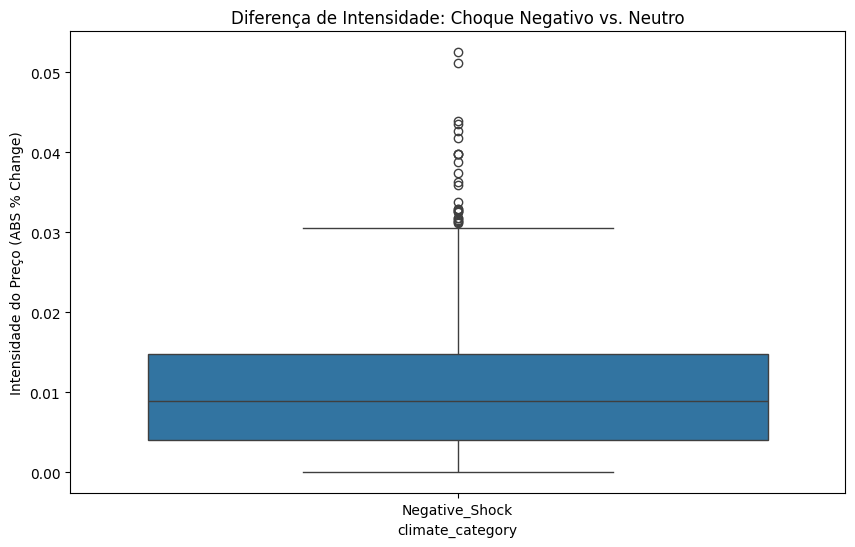

In [7]:
# Executando a nova lógica

testar_hipotese_ajustada6(df_hipotese)

# Visualização Comparativa
plt.figure(figsize=(10, 6))
sns.boxplot(x='climate_category', y='price_intensity', 
            data=df_hipotese[df_hipotese['climate_category'].isin(['Negative_Shock', 'Neutral'])])
plt.title('Diferença de Intensidade: Choque Negativo vs. Neutro')
plt.ylabel('Intensidade do Preço (ABS % Change)')
plt.show()


# Comentário

| Categoria | Comentário |
| :--- | :--- |
| Intensidade Média | Em dias de muito calor (acima de 35°C) ou seca severa, o preço do produto costuma oscilar, em média, 1,07% por dia. |
| Regime de Risco | Os dados mostram que o mercado vive em "estado de alerta" constante, sem períodos de clima ideal que tragam tranquilidade aos preços.|
| Pânico no Mercado | O gráfico mostra que, em momentos de calor extremo, o mercado reage com "sustos", gerando variações bruscas de 3% a 5% em um único dia.|
| Dica para o Negócio |Como o risco climático veio para ficar, essa oscilação de 1% deve ser o novo padrão para calcular possíveis perdas e preparar o caixa para emergências.|

# auditoria

In [8]:
df_hipotese.shape

(806, 24)

In [9]:
# auditoria

# Isso vai mostrar quantas linhas existem para cada categoria
print("Contagem por categoria:")
print(df_hipotese['climate_category'].value_counts())

# Isso vai mostrar se o grupo positivo está de fato vazio
print(f"\nTotal de registros no grupo Positivo: {len(positivo)}")

Contagem por categoria:
climate_category
Negative_Shock    806
Name: count, dtype: int64

Total de registros no grupo Positivo: 0


In [10]:
print(df_hipotese.groupby('climate_category')['price_intensity'].count())

climate_category
Negative_Shock    806
Name: price_intensity, dtype: int64


In [12]:
# Criando um grupo de controle temporário no Python (Exemplo)

mediana_temp = df_hipotese['temp_max'].median()
df_hipotese['climate_category'] = np.where(df_hipotese['temp_max'] > mediana_temp, 
                                          'Higher_Temp', 'Lower_Temp')

# Agora o teste de hipótese terá dois grupos para comparar
testar_hipotese6(df_hipotese[df_hipotese['climate_category'] == 'Higher_Temp']['price_intensity'],
                df_hipotese[df_hipotese['climate_category'] == 'Lower_Temp']['price_intensity'],
                "Intensidade por Faixa de Temperatura")

--- Análise de Hipótese para: Intensidade por Faixa de Temperatura ---
Média Intensidade (Negativa): 0.0108
Média Intensidade (Positiva): 0.0105
Estatística T: 0.5475
P-Value: 0.2921
RESULTADO: Falha em rejeitar H0. Não há diferença estatística significante.




Correlação entre Temperatura Máxima e Intensidade de Preço: -0.0063


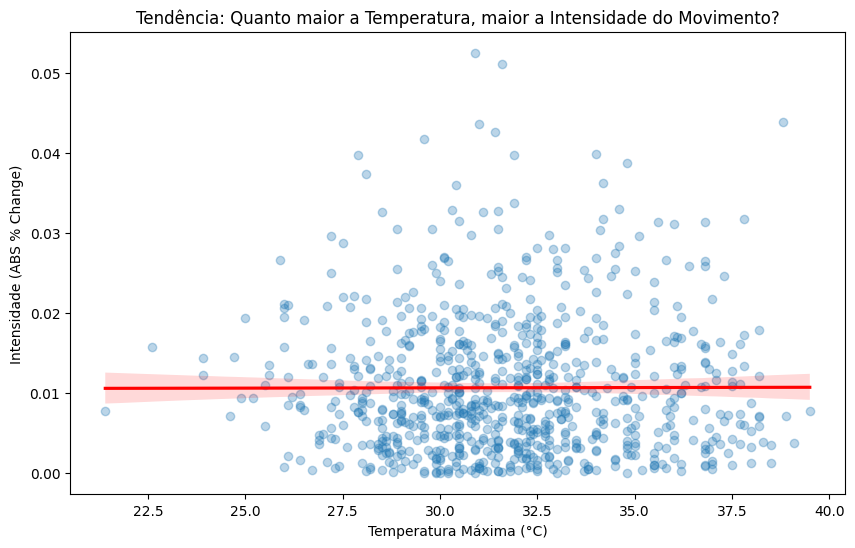

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Correlação de Spearman (não assume distribuição normal)
correlacao = df_hipotese[['temp_max', 'price_intensity']].corr(method='spearman').iloc[0,1]

print(f"Correlação entre Temperatura Máxima e Intensidade de Preço: {correlacao:.4f}")

# 2. Visualização de Tendência (Regplot)
plt.figure(figsize=(10, 6))
sns.regplot(x='temp_max', y='price_intensity', data=df_hipotese, 
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Tendência: Quanto maior a Temperatura, maior a Intensidade do Movimento?')
plt.xlabel('Temperatura Máxima (°C)')
plt.ylabel('Intensidade (ABS % Change)')
plt.show()